# Exp5 map positions - reusable several-fish analysis

Short orchestration notebook derived from `Exp5_map_positions_several.ipynb`. Reusable analysis, summary, and plotting helpers live in `src/`; this notebook keeps only experiment choices and display cells.


In [384]:
# Cell 01 - Setup imports
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import importlib

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import src.data_loading as exio
import src.analysis_tools as at
import src.multifish_analysis as mfa
import src.plotting as plott

importlib.reload(exio)
importlib.reload(at)
importlib.reload(mfa)
importlib.reload(plott)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<module 'src.plotting' from 'c:\\Users\\larsch-lab\\code\\social_filters\\src\\plotting.py'>

Exp 5, left 
"Exp_5_map_positions"

fish_ids = [
    "L684_f01",
    "L684_f07",
    "L733_f01",
    "L733_f06",
    "L733_f07",
]


Exp 7. 

"Exp_7_trans_stat"
fish_ids = [
    "L742_f03",
    "L742_f05",
    "L742_f06",
    "L742_f09",
    "L742_f10",  
]

In [385]:
# Cell 02 - Experiment config
experiment_name = "Exp_2_rocking_1"

def first_existing_path(*candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    tried = "\n".join(str(Path(candidate)) for candidate in candidates)
    raise FileNotFoundError("None of the configured root paths exists:\n" + tried)

onedrive_base = Path(r"D:\Alejandro\Data")
onedrive_candidates = [
    onedrive_base / "OneDrive - Universite de Lausanne",
    *sorted(onedrive_base.glob("OneDrive - Universit* de Lausanne")),
]
onedrive_root = first_existing_path(*onedrive_candidates)
main_path = onedrive_root / "Lab" / "Data" / "2p"
analysis_path = onedrive_root / "Lab" / "Analysis"
stimuli_main_path = analysis_path
save_path = analysis_path / experiment_name / "plots"

fps_2p = 2.0
selected_blocks = [f"B{n}" for n in range(1, 3)]
t_pre_s = 5.0
t_post_s = 32.0
motion_onset_s = 8.0
tau_s = 6.0
motion_duration_key = "motion_sec"

fish_ids = [
    "L472_f02",
    "L472_f03",
    "L472_f04",
    "L472_f06",
]

analysis_label = "Left"
selected_stimuli_to_plot = ["LB", "RL1", "RL2", "RL3", "RLR1", "RLR2"]  # use None for all detected stimuli
left_right_stimuli = ("LB", "RB")
left_right_filter_mode = "none"  # "none", "abs", "left", "right", or "range"
left_right_threshold = 0.3
left_right_range = (-0.3, 0.3)

print("Using main_path:", main_path)
print("Using analysis_path:", analysis_path)


Using main_path: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p
Using analysis_path: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Analysis


In [386]:
# Cell 03 - Load and align all fish
all_fish_data = {}
for fish_id in fish_ids:
    print(f"Loading {fish_id}")
    all_fish_data[fish_id] = exio.load_and_align_2p_experiment(
        fish_id=fish_id,
        experiment_name=experiment_name,
        main_path=main_path,
        stimuli_main_path=stimuli_main_path,
        fps_2p=fps_2p,
        selected_blocks=selected_blocks,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        verbose=False,
    )

reference_fish_id = fish_ids[0]
reference_fish = all_fish_data[reference_fish_id]
print(f"Loaded {len(all_fish_data)} fish")
print("Detected stimuli:", reference_fish["stimuli_names"])


Loading L472_f02
Loaded significant traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L472_f02_Exp_2_rocking_1\03_analysis\functional\plots\significant_traces\L472_f02_significant_traces.npz
Loaded kept_neuron_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L472_f02_Exp_2_rocking_1\03_analysis\functional\plots\filtered_neurons_by_stimuli\L472_f02_kept_neuron_indices.npy
Loaded filtered_roi_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L472_f02_Exp_2_rocking_1\03_analysis\functional\suite2P\merged_dFoF\L472_f02_dFoF_merged_filtered_roi_indices.npy
Loaded z_traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L472_f02_Exp_2_rocking_1\03_analysis\functional\plots\z_core\L472_f02_zcore.npz
Using canonical merged map file: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L472_f02_Exp_2_rocking_1\03_analysis\functional\suite2P\merged_dFoF\L472_f02_dFoF_merged_map.csv
dF

In [387]:
# Cell 04 - Stimulus detection, styles, and plot selection
response_stimuli = list(reference_fish["stimuli_names"])
response_selection = at.resolve_selected_stimuli(
    response_stimuli,
    stimuli_id_map=reference_fish["stimuli_id_map"],
    available_stimuli=reference_fish["trial_aligned_traces_z_core"].keys(),
)
response_stimulus_ids = response_selection["stimulus_ids"]
response_stimulus_labels = response_selection["stimulus_labels"]

def resolve_stimulus_selection(selection, response_stimulus_ids, response_stimulus_labels):
    """Resolve stimulus IDs or exact labels to zero-based positions and labels."""
    if selection is None:
        raise ValueError("selection is required.")
    selection = list(selection)
    if not selection:
        raise ValueError("selection must contain at least one stimulus.")
    if len(response_stimulus_ids) != len(response_stimulus_labels):
        raise ValueError("response_stimulus_ids and response_stimulus_labels must have the same length.")

    id_to_pos = {int(stim_id): pos for pos, stim_id in enumerate(response_stimulus_ids)}
    label_to_pos = {str(label): pos for pos, label in enumerate(response_stimulus_labels)}
    if len(id_to_pos) != len(response_stimulus_ids):
        raise ValueError("response_stimulus_ids contains duplicate IDs.")
    if len(label_to_pos) != len(response_stimulus_labels):
        raise ValueError("response_stimulus_labels contains duplicate labels.")

    selected_indices = []
    selected_labels = []
    for stimulus in selection:
        if isinstance(stimulus, (np.integer, int)):
            stim_id = int(stimulus)
            if stim_id not in id_to_pos:
                raise ValueError(f"Unknown stimulus ID {stim_id!r}. Valid IDs: {list(response_stimulus_ids)!r}")
            pos = id_to_pos[stim_id]
        elif isinstance(stimulus, str):
            if stimulus not in label_to_pos:
                raise ValueError(f"Unknown stimulus label {stimulus!r}. Valid labels: {list(response_stimulus_labels)!r}")
            pos = label_to_pos[stimulus]
        else:
            raise TypeError(f"Stimulus selector {stimulus!r} must be an integer ID or exact label string.")
        selected_indices.append(pos)
        selected_labels.append(response_stimulus_labels[pos])

    return selected_indices, selected_labels

if selected_stimuli_to_plot is None:
    plot_selection_input = response_stimulus_labels
else:
    plot_selection_input = selected_stimuli_to_plot
plot_selection = at.resolve_selected_stimuli(
    plot_selection_input,
    stimuli_id_map=reference_fish["stimuli_id_map"],
    available_stimuli=reference_fish["trial_aligned_traces_z_core"].keys(),
)
plot_stimulus_ids = plot_selection["stimulus_ids"]
plot_stimulus_labels = plot_selection["stimulus_labels"]

stimuli_colors, stimuli_linestyles = plott.build_stimulus_style_maps(
    stimuli_names=response_stimulus_labels,
)
stimuli_ordered = response_stimulus_labels
stimuli_durations = reference_fish["stimuli_durations"]

print("All response stimuli:", response_stimulus_labels)
print("Plot stimuli:", plot_stimulus_labels)


All response stimuli: ['LB', 'RB', 'RL1', 'RL2', 'RL3', 'RLR1', 'RLR2', 'RR1', 'RR2', 'RR3']
Plot stimuli: ['LB', 'RL1', 'RL2', 'RL3', 'RLR1', 'RLR2']


In [388]:
# Cell 05 - Response matrices and response-window validation
response_window_rows = []
for fid in fish_ids:
    fish = all_fish_data[fid]
    for stim_id, stim_label in zip(response_stimulus_ids, response_stimulus_labels):
        key = stim_id if stim_id in fish["trial_aligned_traces_z_core"] else str(stim_id)
        arr = fish["trial_aligned_traces_z_core"][key]
        window = at.compute_response_window_frames(
            n_time=arr.shape[1],
            fps_2p=fps_2p,
            t_pre_s=t_pre_s,
            motion_onset_s=motion_onset_s,
            stimulus=stim_id,
            stimuli_durations=fish["stimuli_durations"],
            stimuli_id_map=fish["stimuli_id_map"],
            tau_s=tau_s,
            motion_duration_key=motion_duration_key,
        )
        response_window_rows.append({
            "fish_id": fid,
            "stimulus": stim_label,
            "stimulus_id": stim_id,
            "n_time": arr.shape[1],
            "start_frame": window["start_frame"],
            "stop_frame": window["stop_frame"],
            "n_response_frames": window["n_frames"],
            "start_s": window["start_s"],
            "end_s": window["end_s"],
        })
response_window_validation = pd.DataFrame(response_window_rows)

response_results = mfa.build_zscore_response_matrices_all_fish(
    all_fish_data=all_fish_data,
    fish_ids=fish_ids,
    selected_stimuli=response_stimulus_labels,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    motion_onset_s=motion_onset_s,
    tau_s=tau_s,
    motion_duration_key=motion_duration_key,
)
response_matrices_by_fish = response_results["response_matrices"]
pooled_response_matrix = response_results["pooled_response_matrix"]
response_row_metadata = response_results["row_metadata"]

shape_summary = pd.DataFrame([
    {
        "fish_id": fid,
        "response_rows": response_matrices_by_fish[fid].shape[0],
        "kept_neurons": len(all_fish_data[fid]["kept_neuron_indices"]),
        "response_columns": response_matrices_by_fish[fid].shape[1],
    }
    for fid in fish_ids
])
print("Pooled response matrix:", pooled_response_matrix.shape)
display(shape_summary)
display(response_window_validation.groupby("stimulus")["n_response_frames"].describe())


Pooled response matrix: (1267, 10)


,fish_id,response_rows,kept_neurons,response_columns
0,L472_f02,378,378,10
1,L472_f03,325,325,10
2,L472_f04,142,142,10
3,L472_f06,422,422,10


,count,mean,std,min,25%,50%,75%,max
stimulus,,,,,,,,
LB,4.0,24.0,0.0,24.0,24.0,24.0,24.0,24.0
RB,4.0,24.0,0.0,24.0,24.0,24.0,24.0,24.0
RL1,4.0,24.0,0.0,24.0,24.0,24.0,24.0,24.0
RL2,4.0,24.0,0.0,24.0,24.0,24.0,24.0,24.0
RL3,4.0,24.0,0.0,24.0,24.0,24.0,24.0,24.0
RLR1,4.0,24.0,0.0,24.0,24.0,24.0,24.0,24.0
RLR2,4.0,24.0,0.0,24.0,24.0,24.0,24.0,24.0
RR1,4.0,24.0,0.0,24.0,24.0,24.0,24.0,24.0
RR2,4.0,24.0,0.0,24.0,24.0,24.0,24.0,24.0


In [389]:
# Cell 06 - Consolidated per-neuron summary table
active_matrices = mfa.build_active_neuron_matrices_all_fish(
    all_fish_data=all_fish_data,
    fish_ids=fish_ids,
    stim_order=response_stimulus_ids,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    tau_s=tau_s,
    active_fraction_threshold=0.20,
    min_epoch_s=1.5,
    min_active_reps=2,
    expected_reps=4,
)

neuron_summary_all_stimuli_table = mfa.build_neuron_stimulus_summary_table(
    response_matrices=response_matrices_by_fish,
    active_matrices=active_matrices,
    row_metadata=response_row_metadata,
    selected_stimulus_ids=response_stimulus_ids,
    selected_stimulus_labels=response_stimulus_labels,
    analysis_label=analysis_label,
)

neuron_summary_table = mfa.build_neuron_stimulus_summary_table(
    response_matrices=response_matrices_by_fish,
    active_matrices=active_matrices,
    row_metadata=response_row_metadata,
    selected_stimulus_ids=plot_stimulus_ids,
    selected_stimulus_labels=plot_stimulus_labels,
    analysis_label=analysis_label,
)
neuron_summary_table = mfa.add_selectivity_metrics_to_summary_table(
    neuron_summary_table,
    selected_stimulus_labels=plot_stimulus_labels,
)

left_right_index = np.full(pooled_response_matrix.shape[0], np.nan, dtype=float)
left_stimulus, right_stimulus = left_right_stimuli
if left_stimulus in pooled_response_matrix.columns and right_stimulus in pooled_response_matrix.columns:
    auc_left = pooled_response_matrix[left_stimulus].to_numpy(dtype=float)
    auc_right = pooled_response_matrix[right_stimulus].to_numpy(dtype=float)
    denom = auc_left + auc_right
    finite = np.isfinite(denom) & (np.abs(denom) > 1e-12)
    left_right_index[finite] = (auc_left[finite] - auc_right[finite]) / denom[finite]
else:
    print("Left/right index skipped because configured control stimuli were not found.")

if left_right_filter_mode == "none":
    plot_neuron_keep_mask = np.ones(pooled_response_matrix.shape[0], dtype=bool)
elif left_right_filter_mode == "abs":
    plot_neuron_keep_mask = np.isfinite(left_right_index) & (np.abs(left_right_index) >= left_right_threshold)
elif left_right_filter_mode == "left":
    plot_neuron_keep_mask = np.isfinite(left_right_index) & (left_right_index >= left_right_threshold)
elif left_right_filter_mode == "right":
    plot_neuron_keep_mask = np.isfinite(left_right_index) & (left_right_index <= -left_right_threshold)
elif left_right_filter_mode == "range":
    lo, hi = left_right_range
    plot_neuron_keep_mask = np.isfinite(left_right_index) & (left_right_index >= lo) & (left_right_index <= hi)
else:
    raise ValueError("left_right_filter_mode must be 'none', 'abs', 'left', 'right', or 'range'.")

plot_neuron_keep_indices = np.flatnonzero(plot_neuron_keep_mask)
neuron_summary_table["left_right_index"] = left_right_index
neuron_summary_table["plot_neuron_keep"] = plot_neuron_keep_mask
neuron_summary_all_stimuli_table["left_right_index"] = left_right_index
neuron_summary_all_stimuli_table["plot_neuron_keep"] = plot_neuron_keep_mask
selected_auc_response_matrix = pooled_response_matrix.loc[plot_neuron_keep_mask, plot_stimulus_labels].copy()

plot_filter_table = response_row_metadata.copy().reset_index(drop=True)
plot_filter_table["left_right_index"] = left_right_index
plot_filter_table["plot_neuron_keep"] = plot_neuron_keep_mask

print("Neuron summary table:", neuron_summary_table.loc[plot_neuron_keep_mask].shape)
print("All-stimuli response table:", neuron_summary_all_stimuli_table.shape)
print(f"Plot filter kept {plot_neuron_keep_indices.size} of {plot_neuron_keep_mask.size} neurons")
display(plot_filter_table.head())


ValueError: Stimulus 6 has 3 repetitions; expected 4.

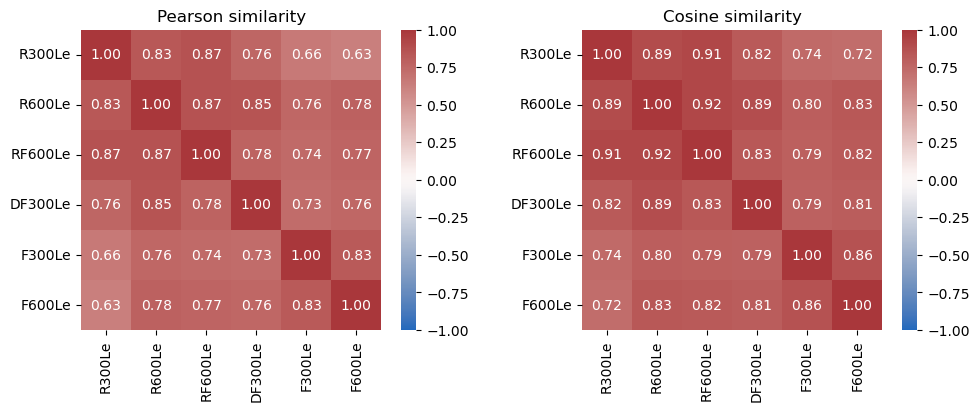

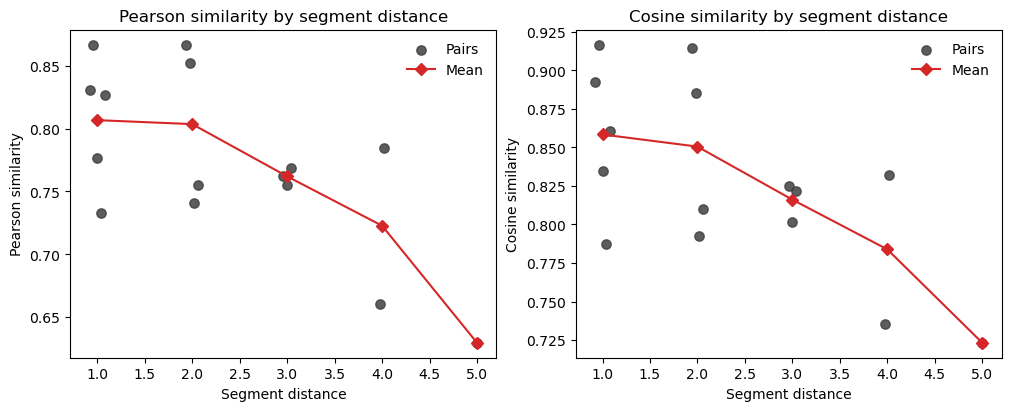

Similarity stimuli: ['R300Le', 'R600Le', 'RF600Le', 'DF300Le', 'F300Le', 'F600Le']


,stimulus_a,stimulus_b,segment_distance,pearson_similarity,cosine_similarity
0,R300Le,R600Le,1,0.830902,0.892274
1,R300Le,RF600Le,2,0.866697,0.914343
2,R300Le,DF300Le,3,0.762055,0.824870
3,R300Le,F300Le,4,0.660910,0.735701
4,R300Le,F600Le,5,0.629744,0.723204
5,R600Le,RF600Le,1,0.866086,0.916720
6,R600Le,DF300Le,2,0.851690,0.885508
7,R600Le,F300Le,3,0.755411,0.801700
8,R600Le,F600Le,4,0.784644,0.831951
9,RF600Le,DF300Le,1,0.776727,0.834820


In [ ]:
# Cell 07 - Stimulus-vector similarity from selected AUC responses
similarity_results = mfa.build_stimulus_vector_similarity(
    selected_auc_response_matrix,
    selected_stimuli=plot_stimulus_labels,
)
pearson_similarity_matrix = similarity_results["pearson_similarity_matrix"]
cosine_similarity_matrix = similarity_results["cosine_similarity_matrix"]
segment_similarity_df = similarity_results["pair_similarity"]

plott.plot_similarity_heatmaps(pearson_similarity_matrix, cosine_similarity_matrix)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
plott.plot_similarity_by_distance(segment_similarity_df, "pearson_similarity", ax=axes[0])
plott.plot_similarity_by_distance(segment_similarity_df, "cosine_similarity", ax=axes[1])
plt.show()

print("Similarity stimuli:", plot_stimulus_labels)
display(segment_similarity_df)


In [ ]:
# # Cell 08 - Segment selectivity permutation summary
# segments_to_compare = ["B1", "B2", "B3", "B4"]
# n_permutations = 1000
# random_seed = 42
# alpha_percentile = 95

# segment_selectivity_results = mfa.build_segment_selectivity_permutation_summary(
#     all_fish_data=all_fish_data,
#     fish_ids=fish_ids,
#     selected_stimulus_ids=plot_stimulus_ids,
#     selected_stimulus_labels=plot_stimulus_labels,
#     segments_to_compare=segments_to_compare,
#     fps_2p=fps_2p,
#     t_pre_s=t_pre_s,
#     motion_onset_s=motion_onset_s,
#     tau_s=tau_s,
#     motion_duration_key=motion_duration_key,
#     n_permutations=n_permutations,
#     random_seed=random_seed,
#     alpha_percentile=alpha_percentile,
# )
# segment_selectivity_summary_df = segment_selectivity_results["summary_df"]
# si_real = segment_selectivity_results["si_real"]
# si_shuffle = segment_selectivity_results["si_shuffle"]
# significant_segment_selective = segment_selectivity_results["significant_segment_selective"]

# segment_columns = [
#     "global_neuron_id",
#     "segment_selectivity_index",
#     "preferred_segment",
#     "segment_shuffle_threshold",
#     "segment_selective",
#     "segment_skip_reason",
# ]
# neuron_summary_table = neuron_summary_table.merge(
#     segment_selectivity_summary_df[segment_columns],
#     on="global_neuron_id",
#     how="left",
#     validate="one_to_one",
# )

# print("Segments used:", segment_selectivity_results["segments_requested"])
# print("Significant selective neurons:", int(np.count_nonzero(significant_segment_selective)))
# print("Skip reasons:", segment_selectivity_results["skip_reason_counts"])
# display(segment_selectivity_results["trial_counts"].head())


In [ ]:
# # Cell 09 - Segment selectivity plot
# finite_shuffle = si_shuffle[np.isfinite(si_shuffle)]
# finite_real = si_real[np.isfinite(si_real)]

# fig_segment_si, ax_segment_si = plt.subplots(figsize=(7, 4.5))
# if finite_shuffle.size > 0:
#     ax_segment_si.hist(finite_shuffle, bins=40, color="0.75", alpha=0.75, density=True, label="shuffled SI")
# if finite_real.size > 0:
#     ax_segment_si.hist(finite_real, bins=25, histtype="step", color="black", linewidth=1.5, density=True, label="real SI")
# ax_segment_si.set_xlabel("selectivity index")
# ax_segment_si.set_ylabel("density")
# ax_segment_si.set_title("Permutation-based segment selectivity")
# ax_segment_si.legend(frameon=False, fontsize=8)
# fig_segment_si.tight_layout()
# plt.show()


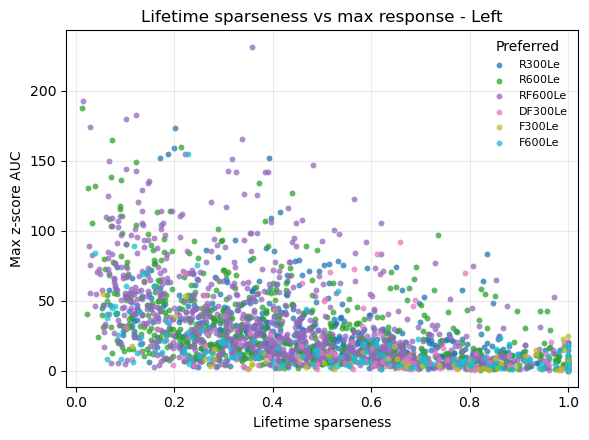

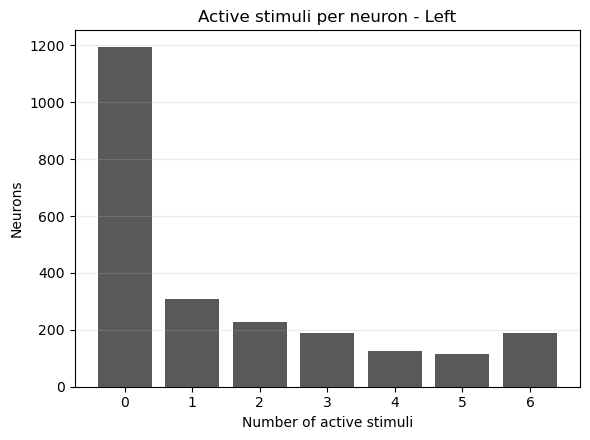

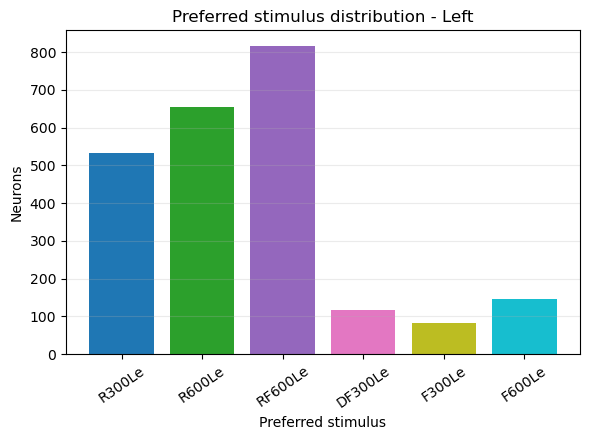

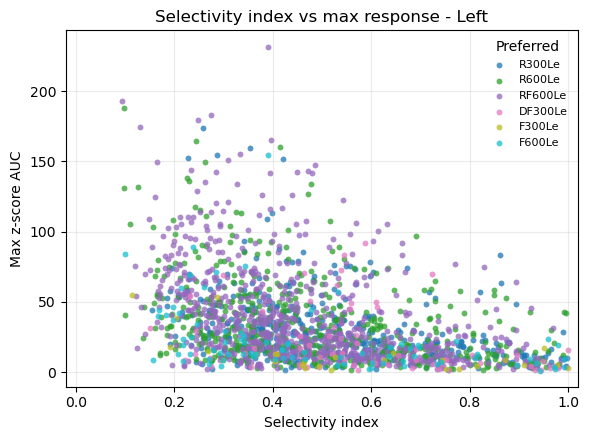

In [ ]:
# Cell 10 - Stimulus specificity summary plots
plot_summary_table = neuron_summary_table.loc[neuron_summary_table["plot_neuron_keep"]].reset_index(drop=True)

fig_stimulus_specificity_sparseness, ax_stimulus_specificity_sparseness = plt.subplots(figsize=(6, 4.5))
plott.plot_stimulus_specificity_sparseness(
    plot_summary_table,
    selected_stimulus_labels=plot_stimulus_labels,
    analysis_label=analysis_label,
    ax=ax_stimulus_specificity_sparseness,
)
fig_stimulus_specificity_sparseness.tight_layout()
plt.show()

fig_active_stimuli_histogram, ax_active_stimuli_histogram = plt.subplots(figsize=(6, 4.5))
plott.plot_active_stimuli_histogram(
    plot_summary_table,
    selected_stimulus_labels=plot_stimulus_labels,
    analysis_label=analysis_label,
    ax=ax_active_stimuli_histogram,
)
fig_active_stimuli_histogram.tight_layout()
plt.show()

fig_preferred_stimulus_distribution, ax_preferred_stimulus_distribution = plt.subplots(figsize=(6, 4.5))
plott.plot_preferred_stimulus_distribution(
    plot_summary_table,
    selected_stimulus_labels=plot_stimulus_labels,
    analysis_label=analysis_label,
    ax=ax_preferred_stimulus_distribution,
)
fig_preferred_stimulus_distribution.tight_layout()
plt.show()

fig_stimulus_specificity_selectivity_index, ax_stimulus_specificity_selectivity_index = plt.subplots(figsize=(6, 4.5))
plott.plot_stimulus_specificity_selectivity_index(
    plot_summary_table,
    selected_stimulus_labels=plot_stimulus_labels,
    analysis_label=analysis_label,
    ax=ax_stimulus_specificity_selectivity_index,
)
fig_stimulus_specificity_selectivity_index.tight_layout()
plt.show()


Notebook-level neuron filter for Cell 11 kept 2350 of 2350 candidate neurons before lifetime-sparseness filtering.
Neurons with lifetime sparseness > 0.65: 663
Preferred stimulus order: ['R300Le', 'R600Le', 'RF600Le', 'DF300Le', 'F300Le', 'F600Le']
Plot stimulus order: [8, 10, 12, 1, 3, 5]
Counts by preferred stimulus:
preferred_stimulus
R300Le     163
R600Le     181
RF600Le    161
DF300Le     58
F300Le      47
F600Le      53
Name: count, dtype: int64


,fish_id,neuron_id,source_neuron_id,global_neuron_id,preferred_stimulus,max_response,lifetime_sparseness
0,L742_f09,186,634,1706,R300Le,83.246830,0.834551
1,L742_f09,177,608,1697,R300Le,63.794993,0.828052
2,L742_f03,365,1158,365,R300Le,57.278049,0.783681
3,L742_f03,368,1164,368,R300Le,57.271790,0.662936
4,L742_f06,151,548,1357,R300Le,52.747285,0.707252


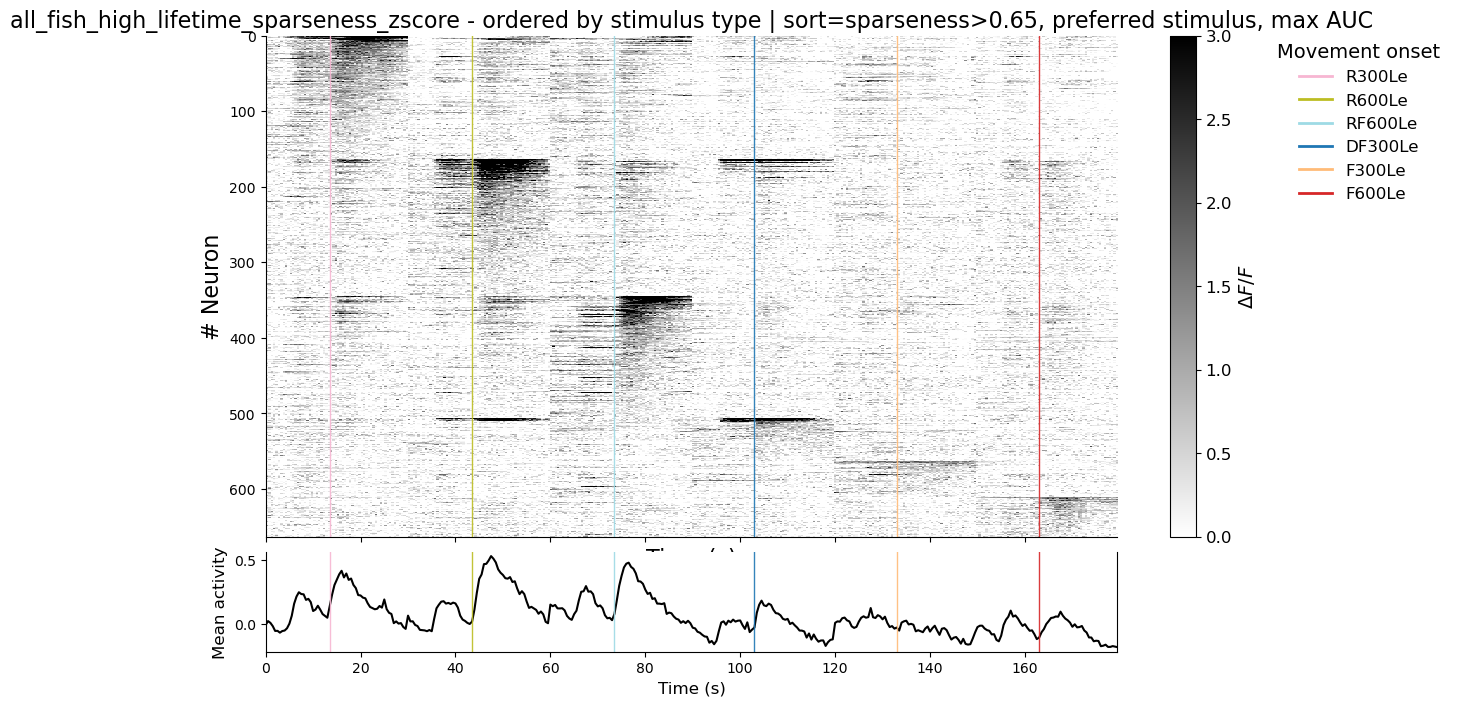

In [ ]:
# Cell 11 - High lifetime-sparseness z-score raster
# Equivalent to the original high-sparseness z-score raster, using the selected plot stimuli.
lifetime_sparseness_threshold = 0.65
high_sparseness_plot_stim_order = plot_stimulus_ids
high_sparseness_preferred_stimulus_order = plot_stimulus_labels
high_sparseness_combine_mode = "mean"
high_sparseness_trace_type = "zscore"

high_sparseness_metric_source_table = neuron_summary_table.copy()
high_sparseness_source_row_count = high_sparseness_metric_source_table.shape[0]

if "plot_neuron_keep_mask" in globals():
    high_sparseness_global_ids = high_sparseness_metric_source_table["global_neuron_id"].to_numpy(dtype=int)
    if plot_neuron_keep_mask.shape[0] <= high_sparseness_global_ids.max(initial=-1):
        raise ValueError(
            "plot_neuron_keep_mask is shorter than the global_neuron_id values in "
            "high_sparseness_metric_source_table."
        )
    high_sparseness_metric_source_table = high_sparseness_metric_source_table.loc[
        plot_neuron_keep_mask[high_sparseness_global_ids]
    ].copy()
    print(
        "Notebook-level neuron filter for Cell 11 kept "
        f"{high_sparseness_metric_source_table.shape[0]} of {high_sparseness_source_row_count} "
        "candidate neurons before lifetime-sparseness filtering."
    )

high_sparseness_response_matrix = mfa.build_matrix_all_fish(
    all_fish_data,
    high_sparseness_plot_stim_order,
    fish_ids=fish_ids,
    combine_mode=high_sparseness_combine_mode,
    trace_type=high_sparseness_trace_type,
)

preference_rank = {
    stimulus: rank
    for rank, stimulus in enumerate(high_sparseness_preferred_stimulus_order)
}
high_sparseness_summary_df = high_sparseness_metric_source_table.loc[
    np.isfinite(high_sparseness_metric_source_table["lifetime_sparseness"])
    & (high_sparseness_metric_source_table["lifetime_sparseness"] > lifetime_sparseness_threshold)
].copy()
high_sparseness_summary_df["_preferred_stimulus_rank"] = (
    high_sparseness_summary_df["preferred_stimulus"]
    .map(preference_rank)
    .fillna(len(preference_rank))
)
high_sparseness_summary_df["_max_auc_sort"] = high_sparseness_summary_df["max_response"].fillna(-np.inf)
high_sparseness_summary_df = high_sparseness_summary_df.sort_values(
    by=["_preferred_stimulus_rank", "_max_auc_sort", "global_neuron_id"],
    ascending=[True, False, True],
    kind="mergesort",
).reset_index(drop=True)

high_sparseness_neuron_order_global = high_sparseness_summary_df["global_neuron_id"].to_numpy(dtype=int)
high_sparseness_zscore_matrix = high_sparseness_response_matrix[high_sparseness_neuron_order_global, :]
high_sparseness_neuron_order = np.arange(high_sparseness_zscore_matrix.shape[0], dtype=int)

print(
    f"Neurons with lifetime sparseness > {lifetime_sparseness_threshold}: "
    f"{high_sparseness_zscore_matrix.shape[0]}"
)
print("Preferred stimulus order:", list(high_sparseness_preferred_stimulus_order))
print("Plot stimulus order:", list(high_sparseness_plot_stim_order))
print("Counts by preferred stimulus:")
print(
    high_sparseness_summary_df["preferred_stimulus"]
    .value_counts()
    .reindex(high_sparseness_preferred_stimulus_order, fill_value=0)
)

display(
    high_sparseness_summary_df[
        [
            "fish_id",
            "neuron_id",
            "source_neuron_id",
            "global_neuron_id",
            "preferred_stimulus",
            "max_response",
            "lifetime_sparseness",
        ]
    ].head()
)

if high_sparseness_zscore_matrix.shape[0] == 0:
    print("No neurons passed the lifetime sparseness threshold; raster was not plotted.")
    fig_high_sparseness_zscore_raster = None
    ax_high_sparseness_zscore_raster = None
    im_high_sparseness_zscore_raster = None
else:
    (
        fig_high_sparseness_zscore_raster,
        ax_high_sparseness_zscore_raster,
        im_high_sparseness_zscore_raster,
        high_sparseness_plot_order,
    ) = plott.plot_allfish_flat_raster(
        data=high_sparseness_zscore_matrix,
        trial_aligned_traces=reference_fish["trial_aligned_traces_z_core"],
        stim_order=high_sparseness_plot_stim_order,
        stimuli_id_map=reference_fish["stimuli_id_map"],
        stimuli_durations=reference_fish["stimuli_durations"],
        stimuli_colors=stimuli_colors,
        stimuli_linestyles=stimuli_linestyles,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        combine_mode=high_sparseness_combine_mode,
        sort_mode="unsorted",
        neuron_order=high_sparseness_neuron_order,
        sort_label=f"sparseness>{lifetime_sparseness_threshold}, preferred stimulus, max AUC",
        is_binary=False,
        show_mean_trace=True,
        figsize=(12, 8),
        fish_id="all_fish_high_lifetime_sparseness_zscore",
        vmax=3,
    )
    plt.show()


Left stimuli: ['R300Le', 'R600Le', 'RF600Le', 'DF300Le', 'F300Le', 'F600Le']
Final matrix shape: (2350, 360)


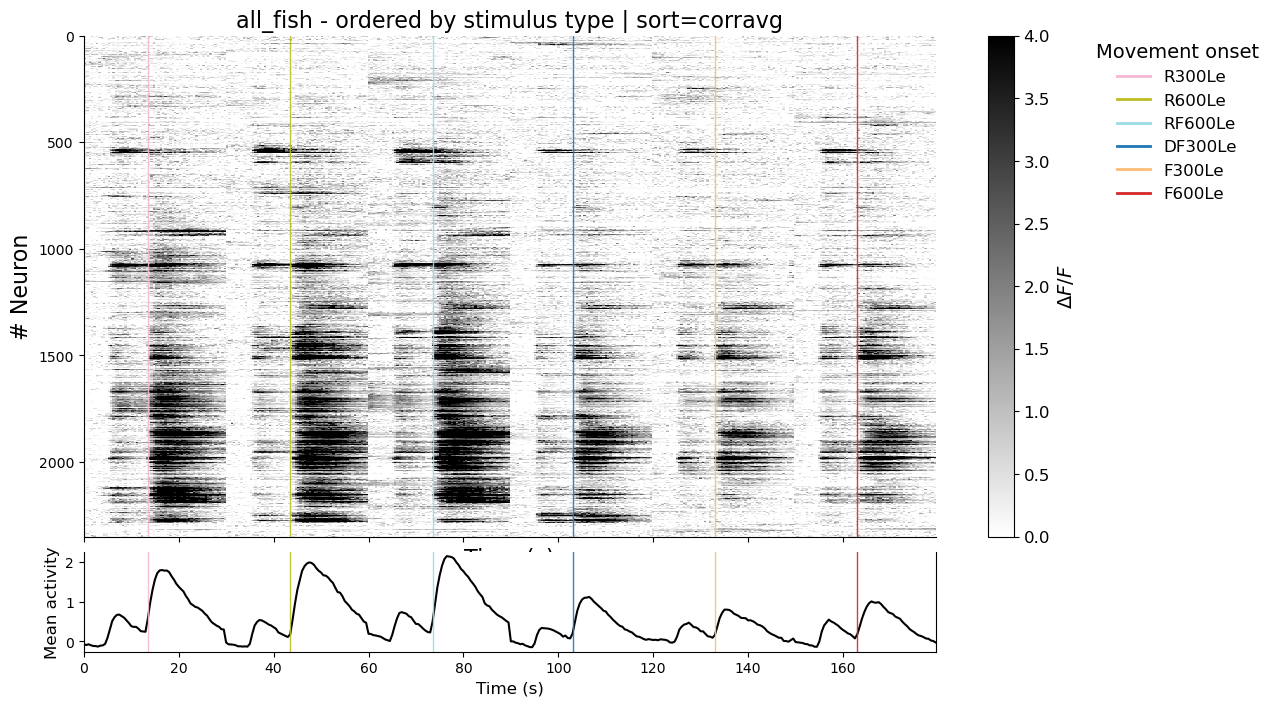

Final matrix shape: (2350, 360)


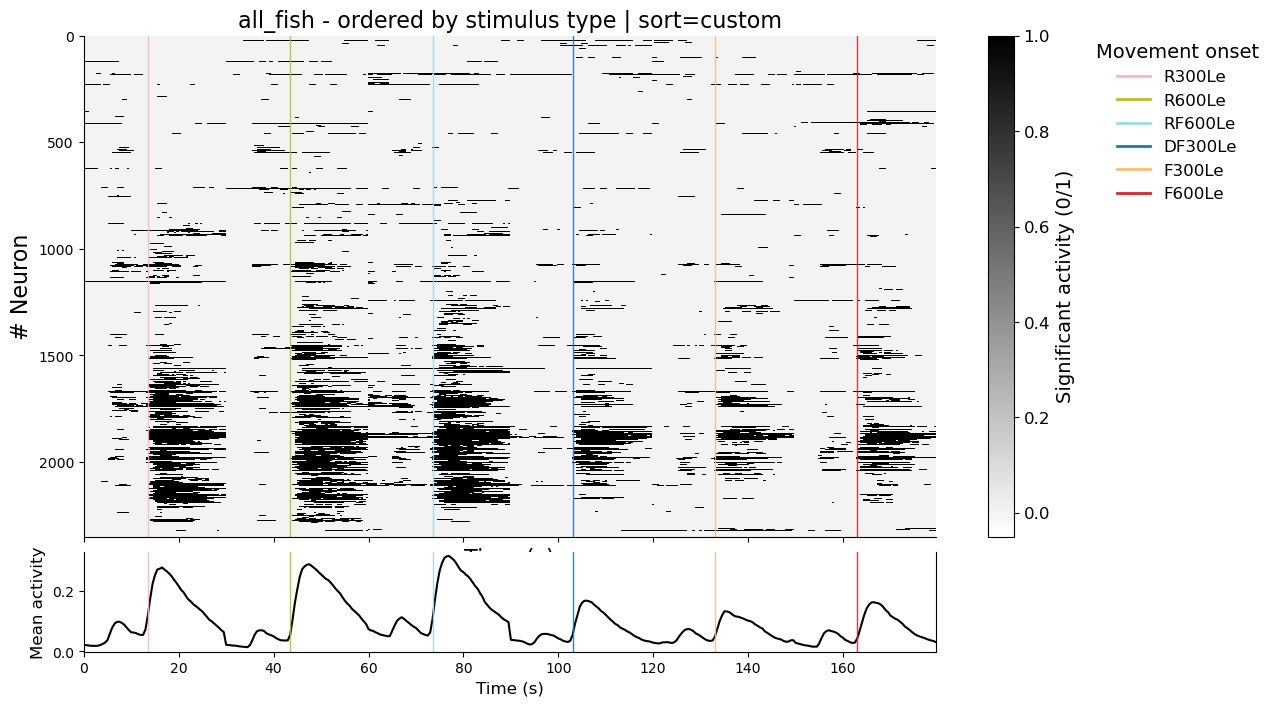

In [ ]:
# Cell 12 - Left z-score and active rasters
# Restores the original pooled left-side z-score and binary active rasters.
#left_stim_order = [7, 3, 4, 5, 6, 1, 13] # ext 5 _left
left_stim_order =['R300Le', 'R600Le', 'RF600Le', 'DF300Le', 'F300Le', 'F600Le']#[7, 8, 10, 12, 1, 3, 5]
left_stim_indices, left_stim_labels = resolve_stimulus_selection(
    left_stim_order,
    response_stimulus_ids,
    response_stimulus_labels,
)
left_stim_ids = [response_stimulus_ids[pos] for pos in left_stim_indices]
left_combine_mode = "mean"
print("Left stimuli:", left_stim_labels)

left_zscore_matrix = mfa.build_matrix_all_fish(
    all_fish_data,
    left_stim_ids,
    fish_ids=fish_ids,
    combine_mode=left_combine_mode,
    trace_type="zscore",
)
if "plot_neuron_keep_mask" in globals():
    if plot_neuron_keep_mask.shape[0] != left_zscore_matrix.shape[0]:
        raise ValueError("plot_neuron_keep_mask length does not match z-score matrix rows.")
    left_zscore_matrix = left_zscore_matrix[plot_neuron_keep_mask, :]
print("Final matrix shape:", left_zscore_matrix.shape)

(
    fig_left_zscore_raster,
    ax_left_zscore_raster,
    im_left_zscore_raster,
    left_zscore_neuron_order,
) = plott.plot_allfish_flat_raster(
    data=left_zscore_matrix,
    trial_aligned_traces=reference_fish["trial_aligned_traces_z_core"],
    stim_order=left_stim_ids,
    stimuli_id_map=reference_fish["stimuli_id_map"],
    stimuli_durations=reference_fish["stimuli_durations"],
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=left_combine_mode,
    sort_mode="corravg",
    n_clusters=3,
    random_state=0,
    neuron_order=None,
    sort_label=None,
    is_binary=False,
    show_mean_trace=True,
    figsize=(12, 8),
    fish_id="all_fish",
    vmax=4,
)
plt.show()

left_active_matrix = mfa.build_matrix_all_fish(
    all_fish_data,
    left_stim_ids,
    fish_ids=fish_ids,
    combine_mode=left_combine_mode,
    trace_type="raster",
)
if "plot_neuron_keep_mask" in globals():
    if plot_neuron_keep_mask.shape[0] != left_active_matrix.shape[0]:
        raise ValueError("plot_neuron_keep_mask length does not match active matrix rows.")
    left_active_matrix = left_active_matrix[plot_neuron_keep_mask, :]
print("Final matrix shape:", left_active_matrix.shape)

(
    fig_left_active_raster,
    ax_left_active_raster,
    im_left_active_raster,
    left_active_neuron_order,
) = plott.plot_allfish_flat_raster(
    data=left_active_matrix,
    trial_aligned_traces=reference_fish["trial_aligned_traces_raster"],
    stim_order=left_stim_ids,
    stimuli_id_map=reference_fish["stimuli_id_map"],
    stimuli_durations=reference_fish["stimuli_durations"],
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=left_combine_mode,
    sort_mode="corravg",
    n_clusters=3,
    random_state=0,
    neuron_order=left_zscore_neuron_order,
    sort_label=None,
    is_binary=True,
    show_mean_trace=True,
    figsize=(12, 8),
    fish_id="all_fish",
    vmax=1,
)
plt.show()


new_stimuli_ids:   [8, 10, 12, 1, 3, 5]
new_stimuli_names: ['R300Le', 'R600Le', 'RF600Le', 'DF300Le', 'F300Le', 'F600Le']
shape of first M: (5, 60)


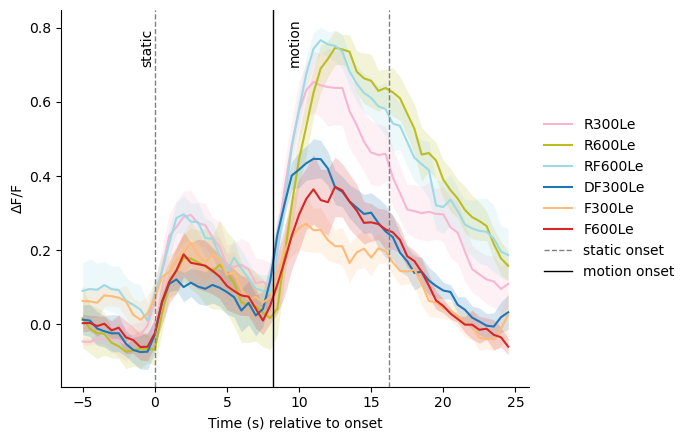

Available stimuli (stim_id, real_name):
id=1, name=DF300Le
id=2, name=DF300Ri
id=3, name=F300Le
id=4, name=F300Ri
id=5, name=F600Le
id=6, name=F600Ri
id=7, name=LeBcontrol
id=8, name=R300Le
id=9, name=R300Ri
id=10, name=R600Le
id=11, name=R600Ri
id=12, name=RF600Le
id=13, name=RF600Ri
id=14, name=RiBcontrol
Selected stimuli (selector, stim_id, real_name):
selector='R300Le', id=8, name=R300Le
selector='R600Le', id=10, name=R600Le
selector='RF600Le', id=12, name=RF600Le
selector='DF300Le', id=1, name=DF300Le
selector='F300Le', id=3, name=F300Le
selector='F600Le', id=5, name=F600Le
Plotting stimuli: ['R300Le', 'R600Le', 'RF600Le', 'DF300Le', 'F300Le', 'F600Le']


(<Figure size 1000x400 with 1 Axes>,
 array([<Axes: title={'center': 'Selected stimuli'}, xlabel='stimulus', ylabel='delta_integral'>],
       dtype=object))

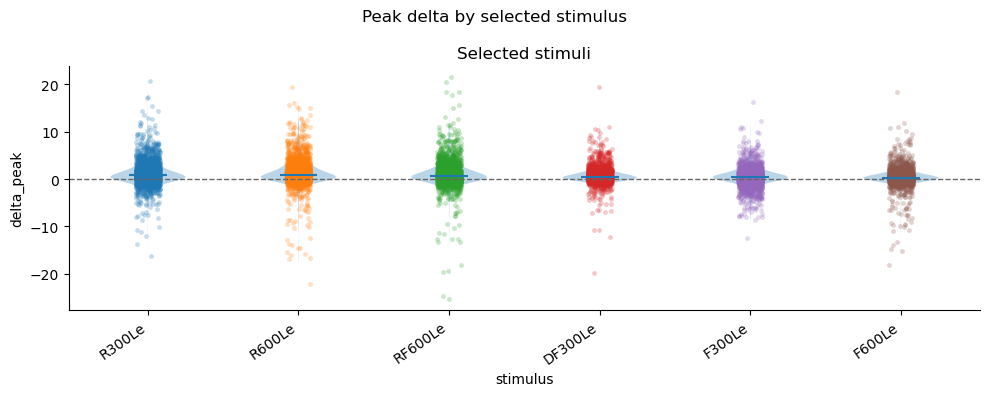

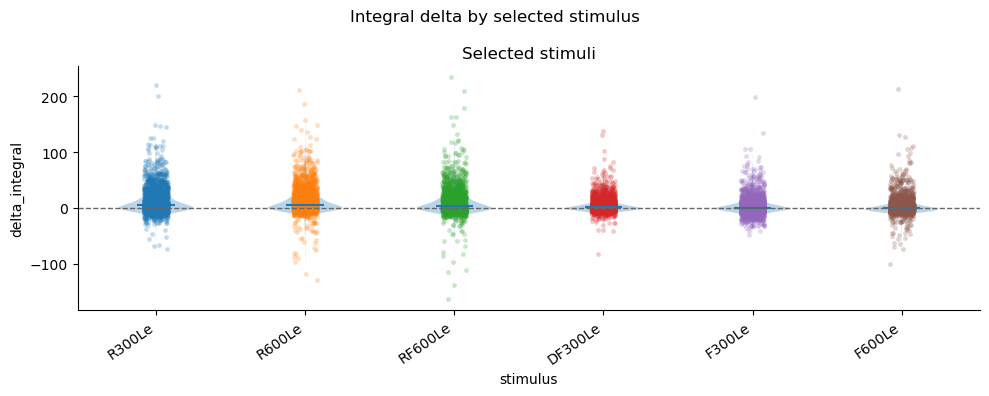

In [ ]:
# Cell 13 - Pooled mean traces and motion-delta distributions
# Restores the original pooled normalized mean traces for seven left-side conditions.

stimuli_wanted = ['R300Le', 'R600Le', 'RF600Le', 'DF300Le', 'F300Le', 'F600Le']


concat_mean_traces = {stim: [] for stim in response_stimulus_ids}
concat_mean_all_neurons = {stim: [] for stim in response_stimulus_ids}
concat_mean_all_neurons_norm = {stim: [] for stim in response_stimulus_ids}

for fid in fish_ids:
    fish = all_fish_data[fid]
    kept_neuron_indices = fish["kept_neuron_indices"]
    for stim in response_stimulus_ids:
        dfof_arr = fish["trial_aligned_traces"][stim]
        dfof_kept = dfof_arr[kept_neuron_indices, :, :]
        mean_trace = np.nanmean(dfof_kept, axis=2)
        concat_mean_traces[stim].append(mean_trace)
        concat_mean_all_neurons[stim].append(np.nanmean(mean_trace, axis=0))

        z_arr = fish["trial_aligned_traces_z_core"][stim]
        mean_trace_norm = np.nanmean(z_arr, axis=2)
        concat_mean_all_neurons_norm[stim].append(np.nanmean(mean_trace_norm, axis=0))

for stim in response_stimulus_ids:
    concat_mean_traces[stim] = np.vstack(concat_mean_traces[stim])
    concat_mean_all_neurons[stim] = np.vstack(concat_mean_all_neurons[stim])
    concat_mean_all_neurons_norm[stim] = np.vstack(concat_mean_all_neurons_norm[stim])


stimuli_ids_for_selection = response_stimulus_ids
stimuli_names_for_selection = response_stimulus_labels
selected_stimuli_indices, selected_stimuli_names = resolve_stimulus_selection(
    stimuli_wanted,
    response_stimulus_ids,
    response_stimulus_labels,
)
selected_stimuli_ids = [response_stimulus_ids[pos] for pos in selected_stimuli_indices]
mean_trace_selection = {stim_id: concat_mean_all_neurons_norm[stim_id] for stim_id in selected_stimuli_ids}

print("new_stimuli_ids:  ", selected_stimuli_ids)
print("new_stimuli_names:", selected_stimuli_names)
print("shape of first M:", mean_trace_selection[selected_stimuli_ids[0]].shape)

fig_mean_traces, ax_mean_traces, used_colors, out_path = plott.plot_stimulus_means(
    mean_traces=mean_trace_selection,
    stimuli_ids=selected_stimuli_ids,
    stimuli_names=selected_stimuli_names,
    title_prefix="",
    fps_2p=fps_2p,
    t_post_s=t_post_s,
    t_pre_s=t_pre_s,
    stimuli_durations=stimuli_durations,
    plots_path=None,
    prefix=None,
    dpi=600,
    save=False,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    close_after=False,
    kept_cells=None,
    comment="all_stimuli",
)

fish_id = fish_ids[0]
fish_data = all_fish_data[fish_id]
print("Available stimuli (stim_id, real_name):")
for stim_id, stim_name in zip(stimuli_ids_for_selection, stimuli_names_for_selection):
    print(f"id={stim_id}, name={stim_name}")
print("Selected stimuli (selector, stim_id, real_name):")
for selector, stim_id, stim_name in zip(stimuli_wanted, selected_stimuli_ids, selected_stimuli_names):
    print(f"selector={selector!r}, id={stim_id}, name={stim_name}")

kept_neuron_indices = fish_data["kept_neuron_indices"]
trial_aligned_z_kept = {
    stim_id: arr[kept_neuron_indices, :, :]
    for stim_id, arr in fish_data["trial_aligned_traces_z_core"].items()
}
selected_trial_aligned_z_kept = {
    stim_id: trial_aligned_z_kept[stim_id]
    for stim_id in selected_stimuli_ids
}

delta_df = at.compute_motion_delta_integrals(
    selected_trial_aligned_z_kept,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    pre_motion_fixed_s=8.0,
    stimuli_id_map=fish_data["stimuli_id_map"],
    stimuli_durations=fish_data["stimuli_durations"],
    fish_id=fish_id,
)
peak_df = at.compute_motion_delta_peaks(
    selected_trial_aligned_z_kept,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    pre_motion_fixed_s=8.0,
    stimuli_id_map=fish_data["stimuli_id_map"],
    stimuli_durations=fish_data["stimuli_durations"],
    fish_id=fish_id,
)
peak_df = peak_df[peak_df["stimulus"].isin(selected_stimuli_names)].copy()
delta_df = delta_df[delta_df["stimulus"].isin(selected_stimuli_names)].copy()

if delta_df.empty or peak_df.empty:
    raise ValueError("No motion-delta rows were computed for the selected stimuli.")
print("Plotting stimuli:", selected_stimuli_names)

plott.plot_motion_delta_distribution(
    peak_df,
    value_col="delta_peak",
    stimuli=selected_stimuli_names,
    title="Peak delta by selected stimulus",
)
plott.plot_motion_delta_distribution(
    delta_df,
    stimuli=selected_stimuli_names,
    title="Integral delta by selected stimulus",
)


Overlap stimuli: {'left': ['LeBcontrol', 'R300Le', 'R600Le', 'RF600Le', 'DF300Le', 'F300Le', 'F600Le'], 'right': ['R300Ri', 'R600Ri', 'RF600Ri']}
Notebook-level neuron filter for pooled overlap kept 2350 of 2350 neurons.


,LeBcontrol,R300Le,R600Le,RF600Le,DF300Le,F300Le,F600Le
LeBcontrol,1.000000,0.368615,0.424543,0.403583,0.205945,0.169862,0.212234
R300Le,0.368615,1.000000,0.581188,0.627389,0.429825,0.351077,0.363420
R600Le,0.424543,0.581188,1.000000,0.624633,0.411111,0.330735,0.397155
RF600Le,0.403583,0.627389,0.624633,1.000000,0.437426,0.341637,0.415403
DF300Le,0.205945,0.429825,0.411111,0.437426,1.000000,0.505092,0.531716
F300Le,0.169862,0.351077,0.330735,0.341637,0.505092,1.000000,0.445736
F600Le,0.212234,0.363420,0.397155,0.415403,0.531716,0.445736,1.000000


,R300Ri,R600Ri,RF600Ri
R300Ri,1.000000,0.675856,0.676892
R600Ri,0.675856,1.000000,0.665112
RF600Ri,0.676892,0.665112,1.000000


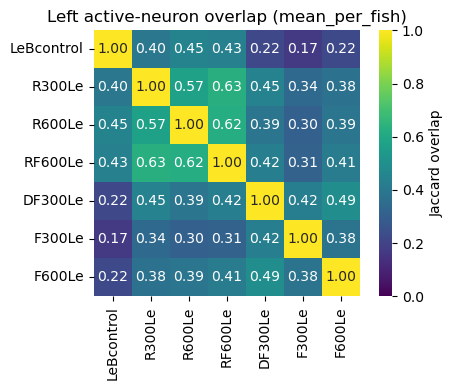

Notebook-level neuron filter kept 2350 of 2350 neurons.


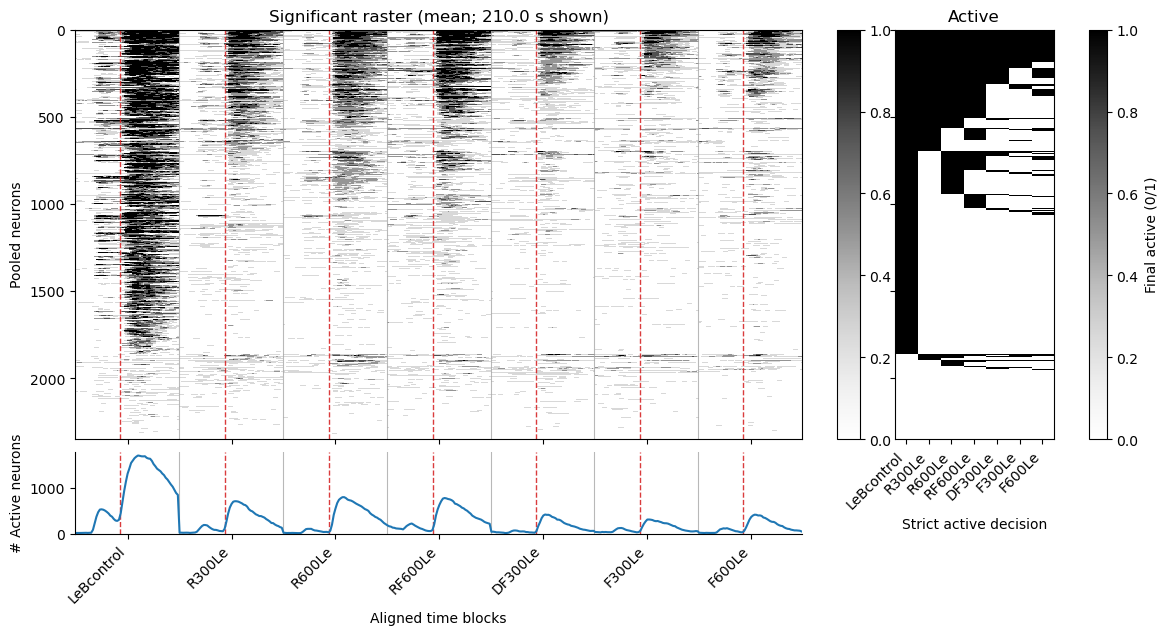

plot_mode: significant_raster
sort_mode: decision_then_mean
trace_matrix: (2350, 420)
decision_matrix: (2350, 7)
Final neuron_summary_table: (2350, 28)


In [ ]:
# cell 14 - Left/right overlap and left-side diagnostic

# ======================
# USER SETTINGS
# ======================

OVERLAP_CONFIG = {
    "plot": "significant_raster",   # "significant_raster" | "z_score"
    "side": "left",                # "left" | "right"
    "aggregation": "mean_per_fish", # "pooled" | "mean_per_fish"

    # Defaults preserve the existing Cell 14 three-condition overlap.
    "stimuli": {
        # "left":  ['R300Le' ,'R600Le','RF600Le','DF300Le','F300Le', 'F600Le'],
        # "right": ['R300Ri', 'R600Ri', 'RF600Ri', 'DF300Ri', 'F300Ri', 'F600Ri'],
        "left":  ['LeBcontrol','R300Le' ,'R600Le','RF600Le', 'DF300Le','F300Le','F600Le'],
        "right": ['R300Ri', 'R600Ri', 'RF600Ri'],
    },

    "diagnostic": {
        "combine_mode": "mean",
        "sort_mode": "decision_then_mean",  # "decision_then_mean" | "left_right_index" | "lifetime_sparseness"
        "show_active_count": True,
        "active_count_threshold": 0.5,
    },

    "heatmap": {
        "figsize": (5, 4),
        "cmap": "viridis",
        "annot": True,
    },
}

valid_plots = {"significant_raster", "z_score"}
valid_sides = {"left", "right"}
valid_aggregations = {"pooled", "mean_per_fish"}
valid_sort_modes = {"decision_then_mean", "left_right_index", "lifetime_sparseness"}
plot_mode = OVERLAP_CONFIG["plot"]
side_to_plot = OVERLAP_CONFIG["side"]
aggregation_to_plot = OVERLAP_CONFIG["aggregation"]
diagnostic_config = OVERLAP_CONFIG["diagnostic"]
heatmap_config = OVERLAP_CONFIG["heatmap"]
diagnostic_sort_mode = diagnostic_config["sort_mode"]
if plot_mode not in valid_plots:
    raise ValueError(f"OVERLAP_CONFIG['plot'] must be one of {sorted(valid_plots)}.")
if side_to_plot not in valid_sides:
    raise ValueError(f"OVERLAP_CONFIG['side'] must be one of {sorted(valid_sides)}.")
if aggregation_to_plot not in valid_aggregations:
    raise ValueError(f"OVERLAP_CONFIG['aggregation'] must be one of {sorted(valid_aggregations)}.")
if diagnostic_sort_mode not in valid_sort_modes:
    raise ValueError(f"diagnostic sort_mode must be one of {sorted(valid_sort_modes)}.")

side_stimuli = OVERLAP_CONFIG["stimuli"]
side_stimulus_ids = {}
side_stimulus_labels = {}
for side, selection in side_stimuli.items():
    side_indices, side_labels = resolve_stimulus_selection(
        selection,
        response_stimulus_ids,
        response_stimulus_labels,
    )
    side_stimulus_ids[side] = [response_stimulus_ids[pos] for pos in side_indices]
    side_stimulus_labels[side] = side_labels
condition_labels = side_stimulus_labels
print("Overlap stimuli:", side_stimulus_labels)

if "active_matrices" not in globals():
    raise RuntimeError("Run Cell 06 first; Cell 14 reuses its active_matrices.")

def subset_cell06_active_matrices(stim_ids):
    subset = {}
    for fid in fish_ids:
        if fid not in active_matrices:
            raise KeyError(f"Fish {fid!r} was not found in Cell 06 active_matrices.")
        active_matrix = active_matrices[fid]
        column_keys = []
        for stim_id in stim_ids:
            if stim_id in active_matrix.columns:
                column_keys.append(stim_id)
            elif str(stim_id) in active_matrix.columns:
                column_keys.append(str(stim_id))
            else:
                raise KeyError(f"Stimulus {stim_id!r} was not found in Cell 06 active_matrices for {fid}.")
        subset[fid] = active_matrix.loc[:, column_keys].copy()
    return subset

active_matrices_overlap = subset_cell06_active_matrices(
    side_stimulus_ids["left"] + side_stimulus_ids["right"]
)

if "plot_neuron_keep_mask" in globals():
    if plot_neuron_keep_mask.shape[0] != response_row_metadata.shape[0]:
        raise ValueError("plot_neuron_keep_mask length does not match response_row_metadata rows.")

    filtered_active_matrices = {}
    for fid in fish_ids:
        fish_rows = response_row_metadata["fish_id"].to_numpy() == fid
        fish_keep_mask = plot_neuron_keep_mask[fish_rows]
        active_matrix = active_matrices_overlap[fid]
        if active_matrix.shape[0] != fish_keep_mask.shape[0]:
            raise ValueError(
                f"Active matrix rows for {fid} do not match response metadata rows: "
                f"{active_matrix.shape[0]} vs {fish_keep_mask.shape[0]}."
            )
        if hasattr(active_matrix, "loc"):
            filtered_active_matrices[fid] = active_matrix.loc[fish_keep_mask].reset_index(drop=True)
        else:
            filtered_active_matrices[fid] = active_matrix[fish_keep_mask, :]
    active_matrices_overlap = filtered_active_matrices
    print(
        "Notebook-level neuron filter for pooled overlap kept "
        f"{int(plot_neuron_keep_mask.sum())} of {plot_neuron_keep_mask.shape[0]} neurons."
    )

overlap_results = {"pooled": {}, "mean_per_fish": {}}
for side, stim_ids in side_stimulus_ids.items():
    side_overlap_results = mfa.build_active_neuron_overlap_matrices_all_fish(
        active_matrices=active_matrices_overlap,
        side_stimuli={side: stim_ids},
        condition_labels=condition_labels[side],
    )
    overlap_results["pooled"][side] = side_overlap_results["pooled"][side]
    overlap_results["mean_per_fish"][side] = side_overlap_results["mean_per_fish"][side]
left_overlap_matrix = overlap_results["pooled"]["left"]
right_overlap_matrix = overlap_results["pooled"]["right"]

matrix_to_plot = overlap_results[aggregation_to_plot][side_to_plot]

display(left_overlap_matrix)
display(right_overlap_matrix)

fig, ax = plt.subplots(figsize=heatmap_config["figsize"])
sns.heatmap(
    matrix_to_plot,
    vmin=0,
    vmax=1,
    square=True,
    annot=heatmap_config["annot"],
    fmt=".2f",
    cmap=heatmap_config["cmap"],
    cbar_kws={"label": "Jaccard overlap"},
    ax=ax,
)
ax.set_title(f"{side_to_plot.capitalize()} active-neuron overlap ({aggregation_to_plot})")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# Active-decision diagnostic using the same Cell 06 active-neuron criterion as the Jaccard plot.
diagnostic_stim_order = side_stimulus_ids[side_to_plot]
diagnostic_combine_mode = diagnostic_config["combine_mode"]
diagnostic_trial_key = {
    "significant_raster": "trial_aligned_traces_raster",
    "z_score": "trial_aligned_traces_z_core",
}[plot_mode]
active_matrices_diagnostic = subset_cell06_active_matrices(diagnostic_stim_order)

def build_diagnostic_trace_source_data(trial_key, stim_order, active_matrices_source):
    if trial_key != "trial_aligned_traces_z_core":
        return all_fish_data

    trace_source_data = {}
    for fid in fish_ids:
        fish = all_fish_data[fid]
        active_row_count = active_matrices_source[fid].shape[0]
        kept_indices = np.asarray(fish["kept_neuron_indices"], dtype=int)
        z_traces = {}
        for stim_id in stim_order:
            key = stim_id if stim_id in fish[trial_key] else str(stim_id)
            arr = fish[trial_key][key]
            if arr.shape[0] == active_row_count:
                z_traces[key] = arr
            elif kept_indices.shape[0] == active_row_count and kept_indices.max(initial=-1) < arr.shape[0]:
                z_traces[key] = arr[kept_indices, :, :]
            else:
                raise ValueError(
                    f"Cannot align z-score rows for {fid}, stimulus {stim_id!r}: "
                    f"trace rows={arr.shape[0]}, active rows={active_row_count}, "
                    f"kept indices={kept_indices.shape[0]}."
                )
        fish_copy = fish.copy()
        fish_copy[trial_key] = z_traces
        trace_source_data[fid] = fish_copy
    return trace_source_data

diagnostic_trace_source_data = build_diagnostic_trace_source_data(
    diagnostic_trial_key,
    diagnostic_stim_order,
    active_matrices_diagnostic,
)
sort_source_diagnostic = mfa.build_pooled_active_trace_diagnostic(
    all_fish_data=all_fish_data,
    active_matrices=active_matrices_diagnostic,
    fish_ids=fish_ids,
    stim_order=diagnostic_stim_order,
    combine_mode=diagnostic_combine_mode,
    trial_key="trial_aligned_traces_raster",
)
active_trace_diagnostic = mfa.build_pooled_active_trace_diagnostic(
    all_fish_data=diagnostic_trace_source_data,
    active_matrices=active_matrices_diagnostic,
    fish_ids=fish_ids,
    stim_order=diagnostic_stim_order,
    combine_mode=diagnostic_combine_mode,
    trial_key=diagnostic_trial_key,
)

def apply_diagnostic_keep_mask(diagnostic, keep_mask):
    diagnostic = diagnostic.copy()
    diagnostic["trace_matrix"] = diagnostic["trace_matrix"][keep_mask, :]
    diagnostic["decision_matrix"] = diagnostic["decision_matrix"][keep_mask, :]
    diagnostic["row_metadata"] = diagnostic["row_metadata"].loc[keep_mask].reset_index(drop=True)
    return diagnostic

if "plot_neuron_keep_mask" in globals():
    if plot_neuron_keep_mask.shape[0] != active_trace_diagnostic["trace_matrix"].shape[0]:
        raise ValueError("plot_neuron_keep_mask length does not match active_trace_diagnostic rows.")
    if plot_neuron_keep_mask.shape[0] != sort_source_diagnostic["trace_matrix"].shape[0]:
        raise ValueError("plot_neuron_keep_mask length does not match sort_source_diagnostic rows.")
    active_trace_diagnostic = apply_diagnostic_keep_mask(active_trace_diagnostic, plot_neuron_keep_mask)
    sort_source_diagnostic = apply_diagnostic_keep_mask(sort_source_diagnostic, plot_neuron_keep_mask)
    print(
        "Notebook-level neuron filter kept "
        f"{int(plot_neuron_keep_mask.sum())} of {plot_neuron_keep_mask.shape[0]} neurons."
    )

def build_metric_sort_order(row_metadata, metric_column, side):
    if metric_column not in neuron_summary_table.columns:
        raise KeyError(f"neuron_summary_table is missing {metric_column!r}.")
    metric_source = neuron_summary_table[["fish_id", "neuron_id", metric_column]].copy()
    order_source = row_metadata.reset_index(names="_diagnostic_row").merge(
        metric_source,
        on=["fish_id", "neuron_id"],
        how="left",
        validate="one_to_one",
    )
    values = order_source[metric_column].to_numpy(dtype=float)
    original_rows = order_source["_diagnostic_row"].to_numpy(dtype=int)
    finite = np.isfinite(values)
    # Missing metric values are kept in the plot but sorted to the bottom.
    missing_rank = np.where(finite, 0, 1)
    if metric_column == "left_right_index" and side == "right":
        metric_rank = np.where(finite, values, np.inf)
    else:
        metric_rank = np.where(finite, -values, np.inf)
    return original_rows[np.lexsort((original_rows, metric_rank, missing_rank))]

def build_decision_then_mean_sort_order(sort_diagnostic):
    trace_matrix = np.asarray(sort_diagnostic["trace_matrix"], dtype=float)
    decision_matrix = np.asarray(sort_diagnostic["decision_matrix"], dtype=int)
    n_neurons = trace_matrix.shape[0]
    if n_neurons == 0:
        return np.array([], dtype=int)
    decision_bits = np.asarray(decision_matrix, dtype=int)
    weights = 2 ** np.arange(decision_bits.shape[1] - 1, -1, -1)
    signatures = decision_bits @ weights
    mean_strength = np.nanmean(trace_matrix, axis=1)
    mean_strength = np.nan_to_num(mean_strength, nan=-np.inf)
    return np.lexsort((-mean_strength, -signatures))

if diagnostic_sort_mode == "decision_then_mean":
    diagnostic_neuron_order = build_decision_then_mean_sort_order(sort_source_diagnostic)
elif diagnostic_sort_mode == "left_right_index":
    diagnostic_neuron_order = build_metric_sort_order(
        active_trace_diagnostic["row_metadata"],
        "left_right_index",
        side_to_plot,
    )
else:
    diagnostic_neuron_order = build_metric_sort_order(
        active_trace_diagnostic["row_metadata"],
        "lifetime_sparseness",
        side_to_plot,
    )

if active_trace_diagnostic["trace_matrix"].shape[0] == 0:
    fig = None
    axes = None
    diagnostic_neuron_order = np.array([], dtype=int)
    print("No neurons passed the current filters; diagnostic plot was not drawn.")
else:
    fig, axes, diagnostic_neuron_order = plott.plot_active_trace_decision_diagnostic(
        active_trace_diagnostic,
        fps_2p=fps_2p,
        stimuli_durations=stimuli_durations,
        t_pre_s=t_pre_s,
        sort_mode=None,
        neuron_order=diagnostic_neuron_order,
        trace_cmap="Greys" if plot_mode == "significant_raster" else "coolwarm",
        show_active_count_trace=diagnostic_config["show_active_count"],
        active_count_threshold=diagnostic_config["active_count_threshold"],
        active_count_ylabel=(
            "# Active neurons"
            if plot_mode == "significant_raster"
            else f"# Neurons >= {diagnostic_config['active_count_threshold']} z"
        ),
        figsize=(12, 7),
    )
    trace_axis = axes[0]
    seconds = active_trace_diagnostic["trace_matrix"].shape[1] / float(fps_2p) if fps_2p > 0 else np.nan
    if plot_mode == "z_score":
        trace_im = trace_axis.images[0]
        finite_trace = active_trace_diagnostic["trace_matrix"][
            np.isfinite(active_trace_diagnostic["trace_matrix"])
        ]
        if finite_trace.size:
            trace_im.set_clim(
                np.nanpercentile(finite_trace, 2),
                np.nanpercentile(finite_trace, 98),
            )
        trace_axis.set_title(f"Z-score ({diagnostic_combine_mode}; {seconds:.1f} s shown)")
        trace_colorbar_axis = fig.axes[2] if diagnostic_config["show_active_count"] else fig.axes[1]
        trace_colorbar_axis.set_ylabel("Z-score")
    else:
        trace_axis.set_title(f"Significant raster ({diagnostic_combine_mode}; {seconds:.1f} s shown)")
    plt.show()

print("plot_mode:", plot_mode)
print("sort_mode:", diagnostic_sort_mode)
print("trace_matrix:", active_trace_diagnostic["trace_matrix"].shape)
print("decision_matrix:", active_trace_diagnostic["decision_matrix"].shape)
print("Final neuron_summary_table:", neuron_summary_table.shape)
